In [25]:
""" Analysis of the results of the sine regression experiment. """

import os
import numpy as np
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scienceplots

sns.set_theme(context='talk', style='ticks',
        font='sans-serif', font_scale=1, color_codes=True, rc={"lines.linewidth": 2})

# plt.style.use(['science', 'no-latex'])

## Set the following matplotlib parameters 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [26]:
df = pd.read_csv('results_all_2000steps.csv')
df.head()

,method,seed,taylor_order,infdim,folder,mse_ind,mse_ood,hours,mins,secs
0,NCF,2024,0,True,240915-042429,1.28e-02,2.09e-02,1.00e+00,5.40e+01,4.30e+01
1,NCF,2024,1,True,240915-062304,1.97e-02,2.92e-02,1.00e+00,5.00e+01,2.00e+00
2,NCF,2024,2,True,240915-081659,1.19e-02,1.25e-02,NaN,NaN,NaN
3,NCF,2024,3,True,240915-100554,7.21e-03,1.02e-02,NaN,NaN,NaN
4,NCF,2024,0,False,240915-121605,9.88e-03,2.73e-02,NaN,NaN,NaN


In [27]:
# ## Make hierachical table with index the tuple (taylor_order, infdim)
# df = df_raw.set_index(['taylor_order', 'infdim'], inplace=False)
# df.sort_index(inplace=True)

# df

## Compute the mean and std of the mse_inf and mse_ood for each taylor order and infdim
taylor_orders = [0,1,2,3]
infdim = [False, True]

all_rows = []
for taylor_order in taylor_orders:
    for infdim_ in infdim:
        ## Extract a subset of the dataframe
        condition = (df['taylor_order'] == taylor_order) & (df['infdim'] == infdim_)
        df_subset = df[condition]
        row_new_df = {'method': f"{'iCSM' if infdim_ else 'CSM'}-{taylor_order}", "mse_ind_mean": df_subset['mse_ind'].mean(), "mse_ind_std": df_subset['mse_ind'].std(), "mse_ood_mean": df_subset['mse_ood'].mean(), "mse_ood_std": df_subset['mse_ood'].std()}

        all_rows.append(row_new_df)


df_mean_std = pd.DataFrame(all_rows)

## Display the dataframe in scientific notation
pd.options.display.float_format = '{:.2e}'.format
df_mean_std


,method,mse_ind_mean,mse_ind_std,mse_ood_mean,mse_ood_std
0,CSM-0,7.93e-03,2.13e-03,1.75e-02,8.49e-03
1,iCSM-0,1.20e-02,1.47e-03,1.86e-02,3.53e-03
2,CSM-1,1.08e-02,3.66e-03,1.66e-02,5.43e-03
3,iCSM-1,1.42e-02,5.41e-03,2.09e-02,7.23e-03
4,CSM-2,3.36e-02,3.78e-02,9.77e-02,1.34e-01
5,iCSM-2,1.39e-02,3.78e-03,3.48e-02,3.73e-02
6,CSM-3,9.83e-03,2.32e-03,1.91e-02,1.83e-03
7,iCSM-3,9.62e-03,2.26e-03,1.48e-02,4.22e-03


In [40]:
## Now we want to plot the training times, 

all_times = []
coda1 = {"method":"CoDA", "hours": 3, "minutes": 42, "seconds": 9}
coda2 = {"method":"CoDA", "hours": 3, "minutes": 44, "seconds": 29}
all_times.append(coda1)
all_times.append(coda2)


## Now open the log files and extract the training times. The log files are in folder of the dataframe. An example line is: "Total gradient descent training time: 1 hours 50 mins 2 secs"
for i, row in df.iterrows():
    log_file = f"NCF/{row['folder']}/nohup.log"
    with open(log_file, 'r') as f:
        lines = f.readlines()
        for line in lines:
            if "Total gradient descent training time" in line:
                time_str = line.split(":")[1].strip()
                hours, minutes, seconds = time_str.split(" ")[::2]
                hours = int(hours)
                minutes = int(minutes)
                seconds = int(seconds)
                if row['taylor_order'] in [0, 1, 2,3]:
                    all_times.append({"method": f"{'$i$CSM' if row['infdim'] else 'CSM'}-{row['taylor_order']}", "hours": hours, "minutes": minutes, "seconds": seconds})
                break

df_times = pd.DataFrame(all_times)
## Add a column with the total time in seconds
# df_times['total_time'] = df_times['hours']*3600 + df_times['minutes']*60 + df_times['seconds']

## Total time in minutes instead
df_times['total_time'] = df_times['hours']*60 + df_times['minutes'] + df_times['seconds']/60

## Sort the dataframe : first all the CoDA, then all the CSM, then all the iCSM
# df_times.sort_values(by=['method'], inplace=True)

df_times


,method,hours,minutes,seconds,total_time
0,CoDA,3,42,9,2.22e+02
1,CoDA,3,44,29,2.24e+02
2,$i$CSM-0,1,54,43,1.15e+02
3,$i$CSM-1,1,50,2,1.10e+02
4,$i$CSM-2,1,45,17,1.05e+02
5,$i$CSM-3,2,6,36,1.27e+02
6,CSM-0,1,31,2,9.10e+01
7,CSM-1,1,26,42,8.67e+01
8,CSM-2,1,54,27,1.14e+02
9,CSM-3,1,46,55,1.07e+02


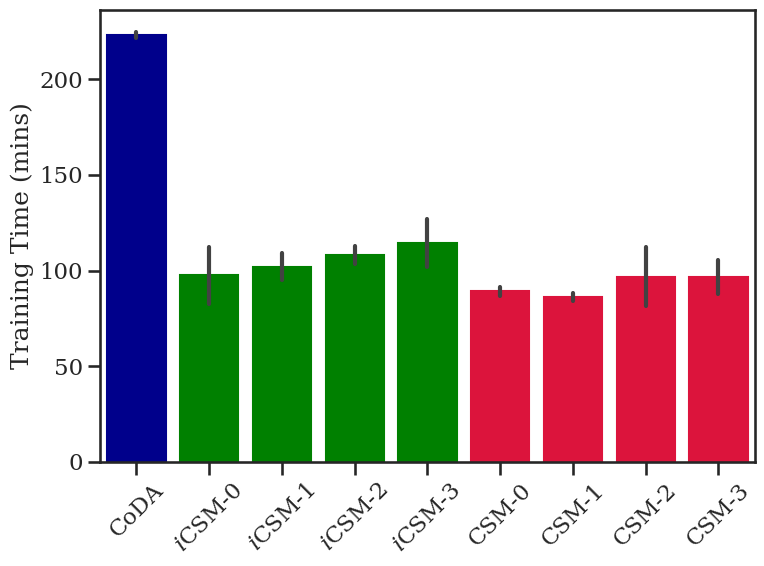

In [48]:
## Plot with seaborn lineplot the total time for each method. On the x axis, we have the method, and on the y axis the total time in seconds. Use the error bars to show the std of the time.
plt.figure(figsize=(8, 6))
sns.barplot(data=df_times, x='method', y='total_time', errorbar='sd')
plt.ylabel('Training Time (mins)')

## Use different colors for the different methods: all CoDA in darkblue, all CSM in lightgreen, all iCSM in crimson
colors_coda = ['darkblue']*1
colors_csm = ['green']*4
colors_icsm = ['crimson']*4
colors = colors_coda + colors_csm + colors_icsm
for i, method in enumerate(df_times['method'].unique()):
    plt.gca().get_children()[i].set_color(colors[i])

## Write the total time on top of the bars
# for i, row in enumerate(df_times['method'].unique()):
    # plt.text(i, row['total_time'], f"{row['total_time']:.2}", ha='center', va='bottom')
    # plt.text(i, row['total_time'], np.round(row['total_time']), ha='center', va='bottom')


plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('total_time.pdf')
plt.show()